In [10]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
  sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "clustering-data-v1"

In [11]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import clustbench

from mstcvi import treelhouette_score, plot_treelhouette, plot_mst_2d

In [12]:
def plot_treelhouette_summary(X, labels, *, show_mst=True, use_markers=True, point_size=20, title=None, 
                              figsize=(12, 5), M=0, **mst_euclid_kwargs):

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

  # Left
  plot_mst_2d(X, labels, ax=ax1, show_mst=show_mst, use_markers=use_markers,
              point_size=point_size, M=M, **mst_euclid_kwargs)
  ax1.set_title("MST partition", fontsize=11)

  # Right
  plot_treelhouette(X, labels, ax=ax2, show_cluster_scores=True, M=M, **mst_euclid_kwargs)

  content_right = 0.84

  if title:
    fig.suptitle(title, fontsize=13, x=content_right / 2, y=0.98)

  plt.tight_layout(rect=[0, 0, content_right, 0.98])

  return fig, (ax1, ax2)

Reproduction of results from the presentation "Yet another graphical aid to the interpretation and validation of cluster analysis"

**jain**

In [13]:
battery = "sipu"
dataset = "jain"
b = clustbench.load_dataset(battery, dataset, path=DATA_PATH)

In [14]:
s = silhouette_score(b.data, b.labels[0])
print(f"Silhouette score: {s:.4f}")

t = treelhouette_score(b.data, b.labels[0])
print(f"Treelhouette score: {t:.4f}")

Silhouette score: 0.4025
Treelhouette score: 0.7370


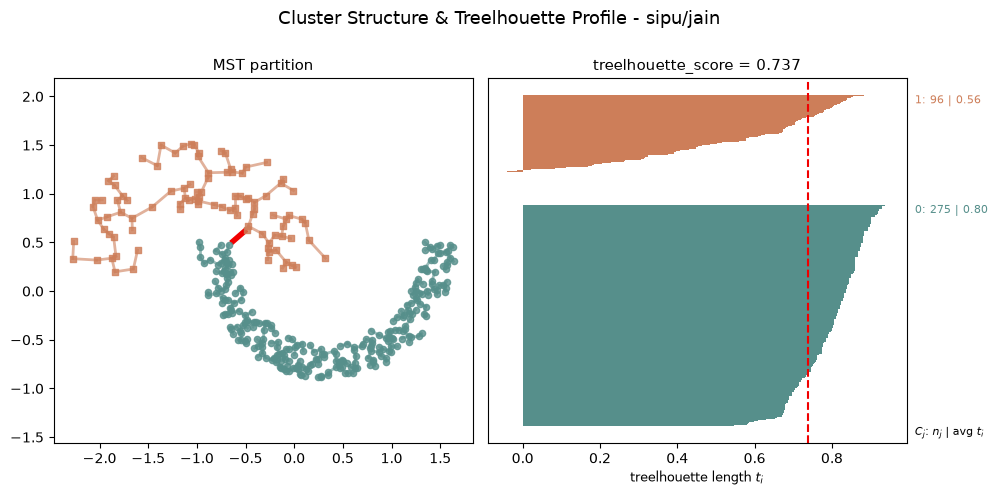

In [15]:
plot_treelhouette_summary(b.data, b.labels[0], title="Cluster Structure & Treelhouette Profile - sipu/jain");

**windows**

In [16]:
battery = "wut"
dataset = "windows"
b = clustbench.load_dataset(battery, dataset, path=DATA_PATH)

In [17]:
s = silhouette_score(b.data, b.labels[0])
print(f"Silhouette score: {s:.4f}")

t = treelhouette_score(b.data, b.labels[0])
print(f"Treelhouette score: {t:.4f}")

Silhouette score: -0.1252
Treelhouette score: 0.9156


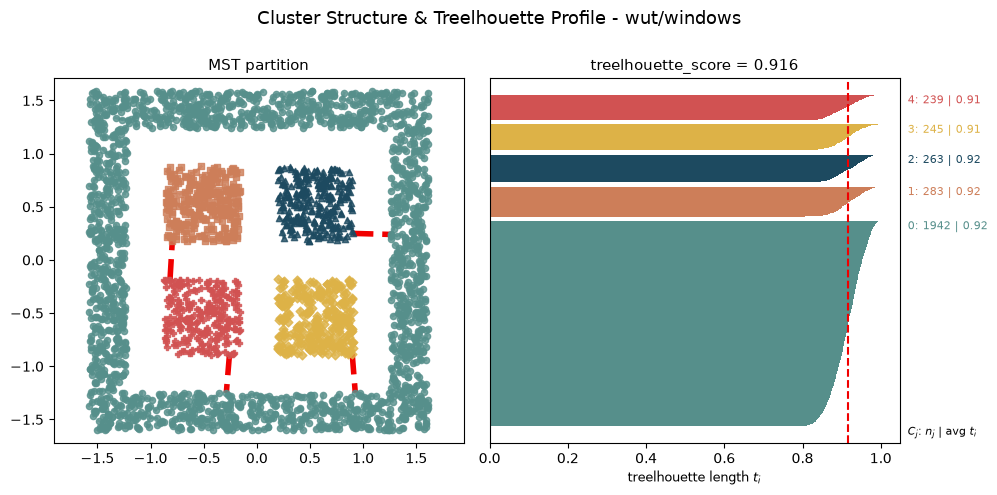

In [18]:
plot_treelhouette_summary(b.data, b.labels[0], title="Cluster Structure & Treelhouette Profile - wut/windows");